<a href="https://colab.research.google.com/github/guupiii/ESAA/blob/main/0508_%EC%84%B8%EC%85%98_RNN_%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 넷플릭스 주가 예측하기 RNN 코드 실습

## 1. 데이터 가져오기

In [4]:
# 데이터 가져오기
import pandas as pd
data = pd.read_csv("netflix_train.csv")
data.head()

,Date,Open,High,Low,Volume,Close
0,2015-12-16,120,123,118,13181000,123
1,2015-12-17,124,126,122,17284900,123
2,2015-12-18,121,122,118,17948100,118
3,2015-12-21,120,120,116,11670000,117
4,2015-12-22,117,117,115,9689000,116


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 967 entries, 0 to 966
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    967 non-null    object
 1   Open    967 non-null    int64 
 2   High    967 non-null    int64 
 3   Low     967 non-null    int64 
 4   Volume  967 non-null    int64 
 5   Close   967 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 45.5+ KB


/tmp/ipykernel_449/2865269528.py:6: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  data.hist(ax=ax, bins=50, edgecolor='black', grid=False)


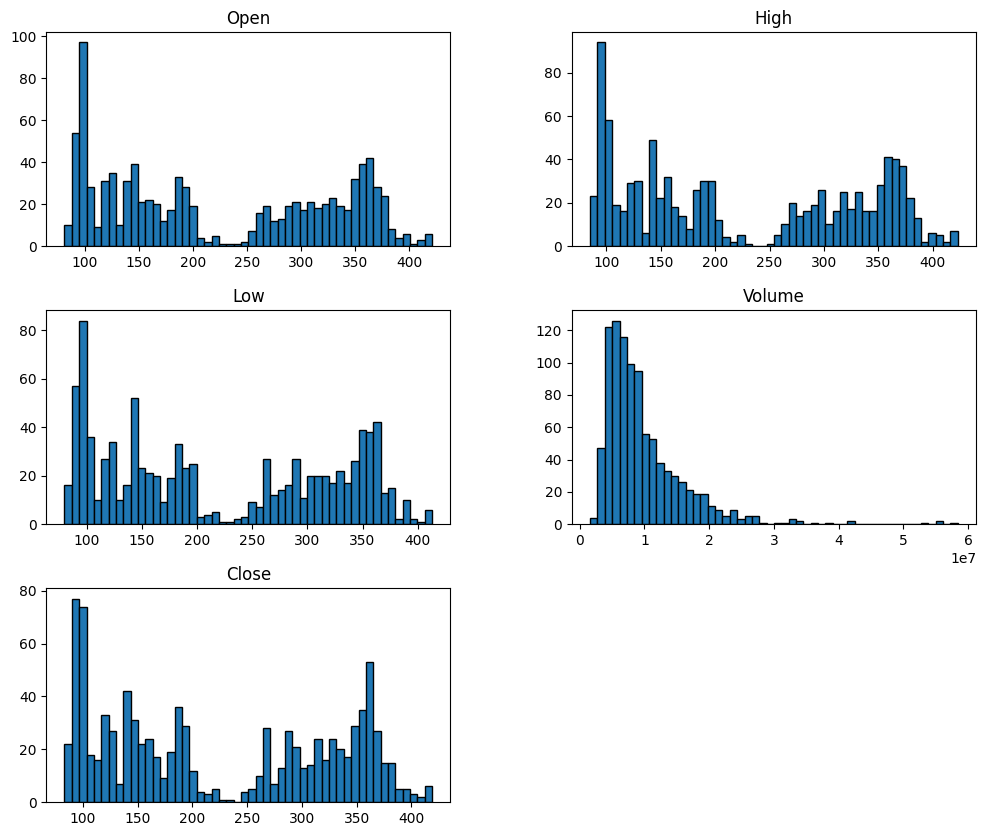

In [7]:
# 데이터 분포를 히스토그램으로 살펴보기
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 10))
# 개장가, 최고가, 최저가 추가
# 종가 추가
data.hist(ax=ax, bins=50, edgecolor='black', grid=False)
plt.show()

## 2. 파이토치 데이터셋 구성하기

In [13]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data.dataset import Dataset

class Netflix(Dataset):
    def __init__(self):
        self.csv = pd.read_csv("netflix_train.csv")
        self.data = self.csv.iloc[:, 1:5].values
        self.data = self.data.astype(np.float32)

        self.min_val = np.min(self.data, axis=0)
        self.max_val = np.max(self.data, axis=0)
        self.data = (self.data - self.min_val) / (self.max_val - self.min_val)

    def __len__(self):
        return len(self.data) - 30

    def __getitem__(self, i):
        data = self.data[i : i + 30]
        label = self.data[i + 30, 3]
        return torch.tensor(data), torch.tensor(label)

## 3. RNN 모델 정의

In [27]:
# RNN 클래스 정의

import torch
import torch.nn as nn

class RNN(nn.Module):
   def __init__(self):
       super(RNN, self).__init__()

       # RNN층의 정의
       self.rnn = nn.RNN(input_size=4, hidden_size=8, num_layers=5, batch_first=True)


       # 주가를 예측하는 MLP층 정의
       self.fc = nn.Linear(in_features=8, out_features=1)


       # 활성화 함수 정의
       self.relu = nn.ReLU()

   # RNN 모델의 순전파 정의
   def forward(self, x, h0):
        # RNN층의 출력: x는 (batch, seq_len, hidden_size)
        x, hn = self.rnn(x, h0)

        # MLP층의 입력으로 사용되게 모양 변경
        # 마지막 시점(30일째)의 hidden state만 추출 -> (batch, 8)
        x = x[:, -1, :]

        # MLP층을 이용해 종가 예측
        x = self.relu(x)
        x = self.fc(x)

        # 예측한 종가를 1차원 벡터로 표현
        x = torch.reshape(x, (-1,))

        return x

## 4. 모델 학습하기

In [28]:
# 모델과 데이터셋 정의
import tqdm
from torch.optim.adam import Adam
from torch.utils.data.dataloader import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

model = RNN().to(device)  # 모델의 정의
dataset = Netflix()       # 데이터셋의 정의

In [29]:
# 데이터로더 정의
loader = DataLoader(dataset, batch_size=32, shuffle=True)  # 배치 크기를 32로 설정

In [30]:
# 최적화 정의
# 학습률은 0.0001로 설정
optim = Adam(model.parameters(), lr=0.0001) # 사용할 최적화 설정

In [31]:
# 학습 루프 정의
# 에포크: 200
for epoch in range(200):
   iterator = tqdm.tqdm(loader)
   for data, label in iterator:
       optim.zero_grad()

       # 초기 은닉 상태
       h0 = torch.zeros(5, data.size(0), 8).to(device)

       # 모델의 예측값
       pred = model(data.to(device), h0)

       # 손실의 계산
       loss = nn.MSELoss()(pred, label.to(device))

       loss.backward()  # 오차 역전파
       optim.step()  # 최적화 진행

       iterator.set_description(f"epoch{epoch} loss:{loss.item()}")

torch.save(model.state_dict(), "rnn.pth")  # 모델 저장

epoch199 loss:0.017729857936501503: 100%|██████████| 30/30 [00:00<00:00, 33.50it/s]


## 5. 모델 성능 평가하기

In [32]:
import matplotlib.pyplot as plt

loader = DataLoader(dataset, batch_size=32, shuffle=False) # 예측값을 위한 데이터로더

preds = [] # 예측값들을 저장하는 리스트
total_loss = 0

with torch.no_grad():
   model.load_state_dict(torch.load("rnn.pth", map_location=device)) # 모델의 가중치 불러오기

   for data, label in loader:
       h0 = torch.zeros(5, data.size(0), 8).to(device) # 초기 은닉 상태 정의

       pred = model(data.to(device), h0) # 모델의 예측값 출력

       preds.extend(pred.detach().cpu().numpy()) # 예측값을 리스트에 추가

       loss = nn.MSELoss()(pred, label.to(device)) # 손실 계산
       total_loss += loss

   total_loss /= len(loader) # 손실의 평균치 계산

total_loss.item()

0.006951470393687487

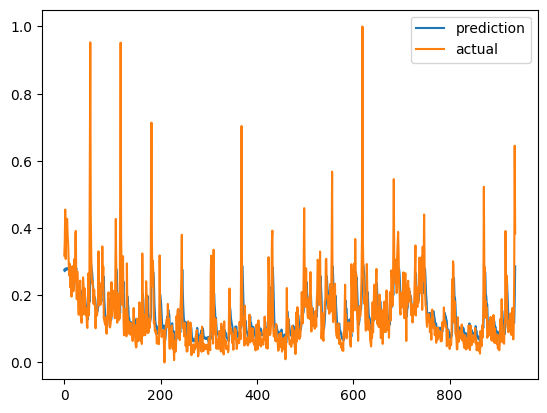

In [34]:
plt.plot(preds, label="prediction")
plt.plot(dataset.data[30:, 3], label="actual")
plt.legend()
plt.show()